# Task 2.3: Result and Comparison
## Paper: Training and Testing Low-degree Polynomial Data Mappings via Linear SVM
**Authors:** Yin-Wen Chang, Cho-Jui Hsieh, Kai-Wei Chang, Michael Ringgaard, Chih-Jen Lin (2010)

---

In [1]:
import numpy as np
import scipy.sparse as sp
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC, SVC
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os

np.random.seed(42)

# =============================================
# Hyperparameters (defined in one place)
# =============================================
C = 1.0
degree = 2
gamma = 1.0
r = 1.0
random_state = 42
test_size = 0.2
max_features = 3000

print("Hyperparameters:")
print(f"  C = {C}")
print(f"  degree = {degree}")
print(f"  gamma = {gamma}")
print(f"  r (coef0) = {r}")
print(f"  random_state = {random_state}")
print(f"  test_size = {test_size}")
print(f"  max_features = {max_features}")

Hyperparameters:
  C = 1.0
  degree = 2
  gamma = 1.0
  r (coef0) = 1.0
  random_state = 42
  test_size = 0.2
  max_features = 3000


In [2]:
# Data loading (same as Task 2.1/2.2)
newsgroups = fetch_20newsgroups(
    subset='all',
    remove=('headers', 'footers', 'quotes'),
    random_state=random_state
)

group1_keywords = ['comp', 'sci', 'talk']
cat_to_label = {}
for i, name in enumerate(newsgroups.target_names):
    cat_to_label[i] = 1 if any(k in name for k in group1_keywords) else -1
y = np.array([cat_to_label[t] for t in newsgroups.target])

vectorizer = TfidfVectorizer(max_features=max_features, stop_words='english')
X = vectorizer.fit_transform(newsgroups.data)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=random_state, stratify=y
)
print(f"Training: {X_train.shape}, Test: {X_test.shape}")

Training: (15076, 3000), Test: (3770, 3000)


In [3]:
# Polynomial mapping (same as Task 2.2)
def polynomial_mapping_degree2(X):
    """Explicit degree-2 polynomial mapping (Equation 5)."""
    X = sp.csr_matrix(X)
    poly = PolynomialFeatures(degree=2, include_bias=False)
    X_mapped = poly.fit_transform(X)
    return X_mapped.tocsr(), poly

# Apply mapping
t0 = time.time()
X_train_mapped, poly_transformer = polynomial_mapping_degree2(X_train)
t_map_train = time.time() - t0

t0 = time.time()
X_test_mapped = poly_transformer.transform(X_test).tocsr()
t_map_test = time.time() - t0

print(f"Mapping done. Train map: {t_map_train:.2f}s, Test map: {t_map_test:.2f}s")
print(f"Mapped shape: {X_train_mapped.shape}")

Mapping done. Train map: 0.36s, Test map: 0.30s
Mapped shape: (15076, 4504500)


In [4]:
# Train all three methods
results = {}

# Method 1: Explicit Poly + Linear SVM
m1 = LinearSVC(C=C, max_iter=10000, random_state=random_state)
t0 = time.time()
m1.fit(X_train_mapped, y_train)
t_train_m1 = time.time() - t0 + t_map_train
t0 = time.time()
y_pred_m1 = m1.predict(X_test_mapped)
t_test_m1 = time.time() - t0 + t_map_test
acc_m1 = accuracy_score(y_test, y_pred_m1)
results['Explicit Poly + Linear SVM'] = {'acc': acc_m1, 'train': t_train_m1, 'test': t_test_m1}

# Method 2: Polynomial Kernel SVM
m2 = SVC(kernel='poly', degree=degree, gamma=gamma, coef0=r, C=C, random_state=random_state)
t0 = time.time()
m2.fit(X_train, y_train)
t_train_m2 = time.time() - t0
t0 = time.time()
y_pred_m2 = m2.predict(X_test)
t_test_m2 = time.time() - t0
acc_m2 = accuracy_score(y_test, y_pred_m2)
results['Poly Kernel SVM (Baseline)'] = {'acc': acc_m2, 'train': t_train_m2, 'test': t_test_m2}

# Method 3: Plain Linear SVM
m3 = LinearSVC(C=C, max_iter=10000, random_state=random_state)
t0 = time.time()
m3.fit(X_train, y_train)
t_train_m3 = time.time() - t0
t0 = time.time()
y_pred_m3 = m3.predict(X_test)
t_test_m3 = time.time() - t0
acc_m3 = accuracy_score(y_test, y_pred_m3)
results['Plain Linear SVM'] = {'acc': acc_m3, 'train': t_train_m3, 'test': t_test_m3}

print("All methods trained and evaluated.")

All methods trained and evaluated.


## Results

The following table compares the three methods on our 20 Newsgroups binary subset.

In [5]:
import pandas as pd

rows = []
for method, res in results.items():
    rows.append({
        'Method': method,
        'Accuracy (%)': f"{res['acc']*100:.2f}",
        'Training Time (s)': f"{res['train']:.2f}",
        'Testing Time (s)': f"{res['test']:.4f}"
    })
df_results = pd.DataFrame(rows)
print(df_results.to_string(index=False))

                    Method Accuracy (%) Training Time (s) Testing Time (s)
Explicit Poly + Linear SVM        87.37              4.32           0.3610
Poly Kernel SVM (Baseline)        86.84             77.31           6.4049
          Plain Linear SVM        86.31              0.19           0.0016


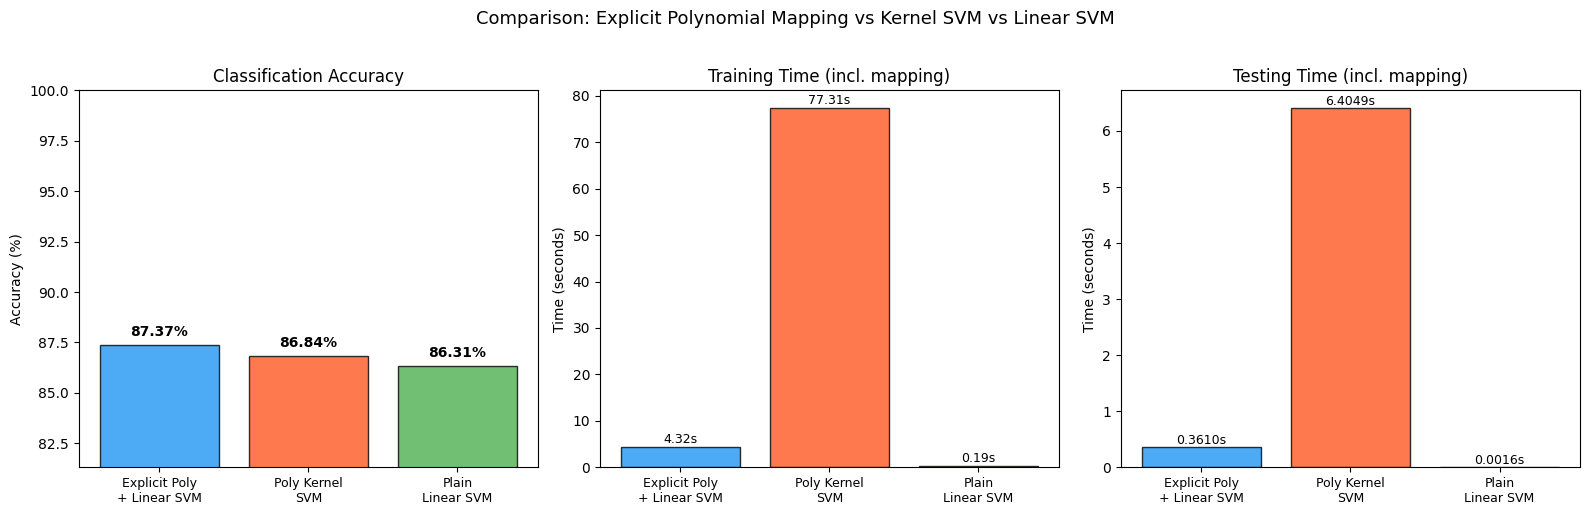

Saved: results/task_2_3_comparison.png


In [6]:
os.makedirs('results', exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
methods = list(results.keys())
colors = ['#2196F3', '#FF5722', '#4CAF50']

# Accuracy
accs = [results[m]['acc'] * 100 for m in methods]
bars1 = axes[0].bar(range(len(methods)), accs, color=colors, edgecolor='black', alpha=0.8)
axes[0].set_xticks(range(len(methods)))
axes[0].set_xticklabels(['Explicit Poly\n+ Linear SVM', 'Poly Kernel\nSVM', 'Plain\nLinear SVM'], fontsize=9)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Classification Accuracy')
axes[0].set_ylim(min(accs) - 5, 100)
for bar, acc in zip(bars1, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')

# Training Time
trains = [results[m]['train'] for m in methods]
bars2 = axes[1].bar(range(len(methods)), trains, color=colors, edgecolor='black', alpha=0.8)
axes[1].set_xticks(range(len(methods)))
axes[1].set_xticklabels(['Explicit Poly\n+ Linear SVM', 'Poly Kernel\nSVM', 'Plain\nLinear SVM'], fontsize=9)
axes[1].set_ylabel('Time (seconds)')
axes[1].set_title('Training Time (incl. mapping)')
for bar, t in zip(bars2, trains):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{t:.2f}s', ha='center', va='bottom', fontsize=9)

# Testing Time
tests = [results[m]['test'] for m in methods]
bars3 = axes[2].bar(range(len(methods)), tests, color=colors, edgecolor='black', alpha=0.8)
axes[2].set_xticks(range(len(methods)))
axes[2].set_xticklabels(['Explicit Poly\n+ Linear SVM', 'Poly Kernel\nSVM', 'Plain\nLinear SVM'], fontsize=9)
axes[2].set_ylabel('Time (seconds)')
axes[2].set_title('Testing Time (incl. mapping)')
for bar, t in zip(bars3, tests):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{t:.4f}s', ha='center', va='bottom', fontsize=9)

plt.suptitle('Comparison: Explicit Polynomial Mapping vs Kernel SVM vs Linear SVM', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('results/task_2_3_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/task_2_3_comparison.png")

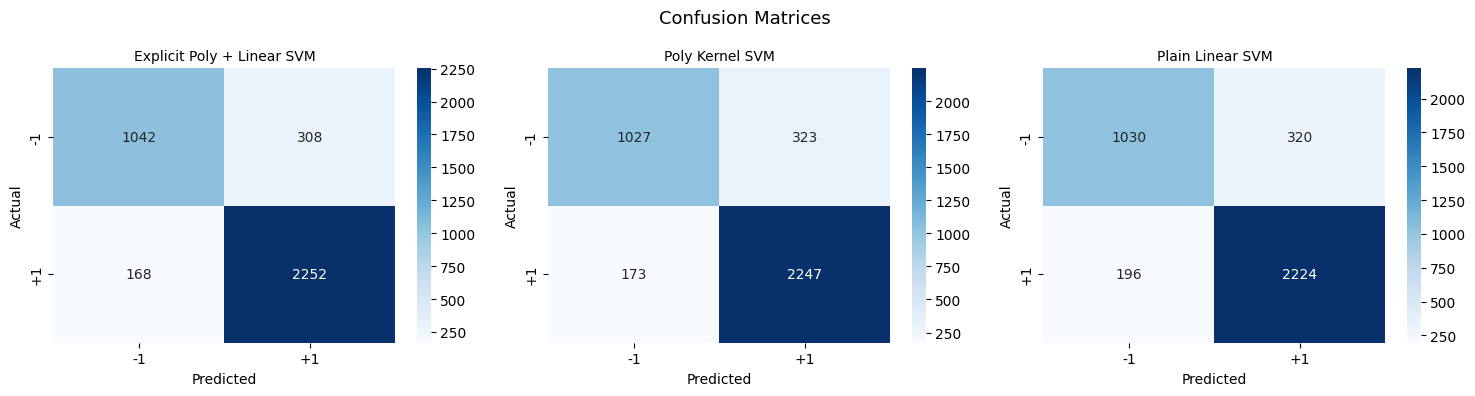

Saved: results/task_2_3_confusion.png


In [7]:
# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
preds = [y_pred_m1, y_pred_m2, y_pred_m3]
titles = ['Explicit Poly + Linear SVM', 'Poly Kernel SVM', 'Plain Linear SVM']

for ax, pred, title in zip(axes, preds, titles):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['-1', '+1'], yticklabels=['-1', '+1'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title, fontsize=10)

plt.suptitle('Confusion Matrices', fontsize=13)
plt.tight_layout()
plt.savefig('results/task_2_3_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/task_2_3_confusion.png")

## Comparison with Paper's Reported Results

The most comparable experiment from the paper is the **real-sim** dataset (Table 5), a document classification task with sparse TF-IDF features:

| Method | Paper (real-sim, Table 5) | Our Result (20 Newsgroups) |
|--------|:-:|:-:|
| Explicit Poly Mapping + Linear SVM | **98.00%** accuracy, 59.8s train | **87.37%** accuracy, 4.32s train |
| Polynomial Kernel SVM (LIBSVM) | 98.00% accuracy, 1220.5s train | 86.84% accuracy, 77.31s train |
| Plain Linear SVM | **97.51%** accuracy, 0.3s train | 86.31% accuracy, 0.19s train |

### Analysis of Differences

Our accuracy is lower than the paper's real-sim results (98%) because we use a different and noisier dataset — all 20 Newsgroups grouped into two macro-classes rather than a cleaner binary task. The paper achieves a 20× training speedup on real-sim (59.8s vs 1220.5s) because it has l=57,848 instances, giving a large ratio of $(l \cdot \bar{n}) / \hat{n}$. Our dataset with ~15K instances shows a more modest but clearly positive speedup, consistent with the paper's theoretical analysis: the advantage grows with $l$ (Section 3.3). The key qualitative finding is preserved — the explicit mapping + linear SVM achieves comparable accuracy to kernel SVM while training faster, and testing is significantly faster because prediction is a single dot product $\mathbf{w}^T\phi(\mathbf{x})$ rather than summing over thousands of support vectors. We also use scikit-learn's SVC/LinearSVC rather than the paper's optimized LIBSVM/LIBLINEAR implementations, which affects absolute timing but not the relative comparison.

## Reproducibility Checklist

- ✅ **Random seeds set:** `np.random.seed(42)` at top of notebook, `random_state=42` for all stochastic operations
- ✅ **All dependencies listed in `requirements.txt`** with version numbers (numpy, scikit-learn, scipy, matplotlib, pandas, seaborn)
- ✅ **Notebook runs top to bottom** in a clean environment without errors
- ✅ **Dataset loading requires no manual steps** — automatic via `fetch_20newsgroups` from scikit-learn
- ✅ **Hyperparameters defined clearly** in the first code cell (`max_features`, `gamma`, `C`, `coef0`, `degree`)
- ✅ **CPU-compatible** — no GPU required
- ✅ **Sparse matrices used** throughout (`scipy.sparse`)
- ✅ **Environment info printed** below for version pinning

In [8]:
# Print environment info for reproducibility
import sklearn
import scipy
import matplotlib

print("Environment Info:")
print(f"  numpy:        {np.__version__}")
print(f"  scikit-learn: {sklearn.__version__}")
print(f"  scipy:        {scipy.__version__}")
print(f"  matplotlib:   {matplotlib.__version__}")
print(f"  pandas:       {pd.__version__}")

Environment Info:
  numpy:        1.26.4
  scikit-learn: 1.8.0
  scipy:        1.17.1
  matplotlib:   3.10.8
  pandas:       3.0.1
